# Análise Exploratória dos Dados — Booklog

## Integrantes

- Gabriel Nottoli Buck — RA 10425384 — 10425384@mackenzista.com.br
- Julia Andrade — RA 10427828 — 10427828@mackenzista.com.br
- João Vitor Rocha Miranda — RA 10427273 — 10427273@mackenzista.com.br
- Juan Nacif - RA 10428509

## Descrição

Este notebook realiza a análise exploratória e a preparação do conjunto de dados da N1 do projeto de recomendação personalizada de livros. O conjunto foi elaborado pelo grupo e autorizado para a atividade.

## Histórico de alterações

| Data | Autor | Alteração |
|---|---|---|
| 15/09/2026 | Grupo | Criação da análise exploratória da N1 |
| 15/09/2026 | Grupo | Revisão editorial, validação e execução integral |

## 1. Carregamento

A base possui dois arquivos: catálogo de livros (`books.csv`) e avaliações (`ratings.csv`).

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

books = pd.read_csv(RAW / "books.csv")
ratings = pd.read_csv(RAW / "ratings.csv")

ratings["rating"] = pd.to_numeric(ratings["rating"], errors="raise")
ratings["interaction_date"] = pd.to_datetime(ratings["interaction_date"], errors="raise")

print("books:", books.shape)
print("ratings:", ratings.shape)
display(books.head())
display(ratings.head())

books: (36, 4)
ratings: (345, 4)


,book_id,title,author,genres
0,B001,1984,George Orwell,Distopia
1,B002,A Revolução dos Bichos,George Orwell,Distopia
2,B003,Admirável Mundo Novo,Aldous Huxley,Distopia
3,B004,Fahrenheit 451,Ray Bradbury,Distopia
4,B005,O Conto da Aia,Margaret Atwood,Distopia


,user_id,book_id,rating,interaction_date
0,U001,B023,3.0,2026-08-22
1,U001,B024,4.0,2026-08-28
2,U001,B021,2.5,2026-08-31
3,U001,B008,5.0,2026-09-01
4,U001,B035,2.0,2026-09-02


## 2. Qualidade e integridade dos dados

In [2]:
quality = pd.DataFrame({
    "arquivo": ["books", "ratings"],
    "linhas": [len(books), len(ratings)],
    "valores_ausentes": [int(books.isna().sum().sum()), int(ratings.isna().sum().sum())],
    "linhas_duplicadas": [int(books.duplicated().sum()), int(ratings.duplicated().sum())],
})
display(quality)

print("book_id duplicados:", int(books["book_id"].duplicated().sum()))
print("pares leitor-livro duplicados:", int(ratings.duplicated(["user_id", "book_id"]).sum()))
print("notas fora da escala:", int((~ratings["rating"].between(1, 5)).sum()))
print("livros das avaliações ausentes do catálogo:", len(set(ratings["book_id"]) - set(books["book_id"])))

book_id duplicados: 0
pares leitor-livro duplicados: 0
notas fora da escala: 0
livros das avaliações ausentes do catálogo: 0


,arquivo,linhas,valores_ausentes,linhas_duplicadas
0,books,36,0,0
1,ratings,345,0,0


## 3. Estatísticas gerais

In [3]:
n_users = ratings["user_id"].nunique()
n_books = books["book_id"].nunique()
n_ratings = len(ratings)
rated_books = ratings["book_id"].nunique()
sparsity = 1 - n_ratings / (n_users * rated_books)

summary = pd.Series({
    "leitores": n_users,
    "livros": n_books,
    "livros avaliados": rated_books,
    "avaliações": n_ratings,
    "nota média": ratings["rating"].mean(),
    "mediana": ratings["rating"].median(),
    "esparsidade": sparsity,
})
display(summary.to_frame("valor"))

,valor
leitores,30.000000
livros,36.000000
livros avaliados,36.000000
avaliações,345.000000
nota média,3.620290
mediana,3.500000
esparsidade,0.680556


## 4. Distribuição das notas

,quantidade
rating,
1.0,1
1.5,7
2.0,20
2.5,37
3.0,48
3.5,75
4.0,64
4.5,45
5.0,48


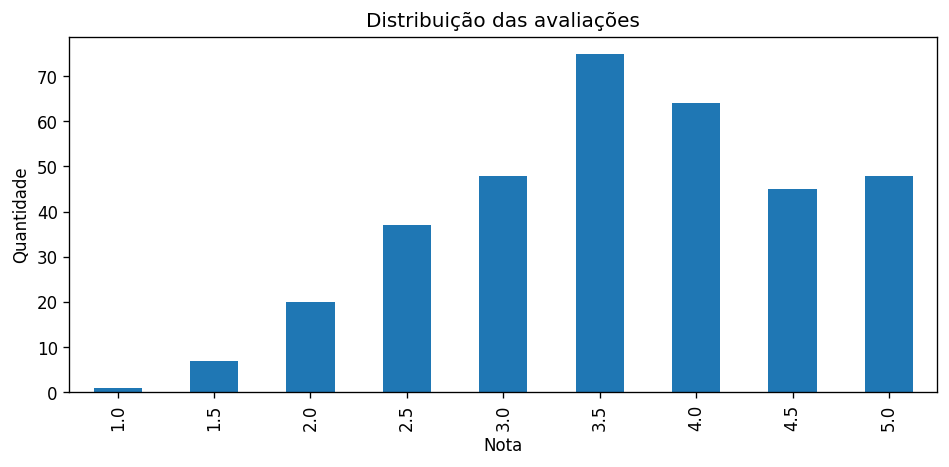

In [4]:
rating_counts = ratings["rating"].value_counts().sort_index()
display(rating_counts.rename("quantidade").to_frame())

ax = rating_counts.plot(kind="bar", figsize=(8, 4), title="Distribuição das avaliações")
ax.set_xlabel("Nota")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

## 5. Interações por leitor

,avaliações por leitor
count,30.000000
mean,11.500000
std,1.852305
min,9.000000
25%,10.000000
50%,11.000000
75%,13.000000
max,15.000000


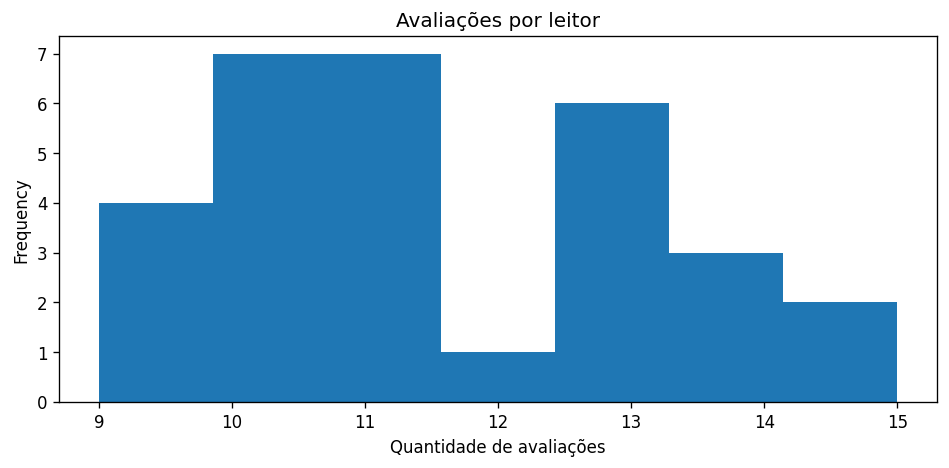

In [5]:
ratings_per_user = ratings.groupby("user_id").size()
display(ratings_per_user.describe().to_frame("avaliações por leitor"))

ax = ratings_per_user.plot(kind="hist", bins=7, figsize=(8, 4), title="Avaliações por leitor")
ax.set_xlabel("Quantidade de avaliações")
plt.tight_layout()
plt.show()

## 6. Interações por livro

,title,genres,avaliações
book_id,,,
B009,Harry Potter e a Pedra Filosofal,Fantasia,21
B014,Duna,Ficção Científica,20
B031,Dom Casmurro,Clássico,18
B016,Neuromancer,Ficção Científica,16
B019,Orgulho e Preconceito,Romance,14
B011,As Crônicas de Nárnia,Fantasia,13
B008,A Sociedade do Anel,Fantasia,12
B015,"Eu, Robô",Ficção Científica,12
B022,Como Eu Era Antes de Você,Romance,12


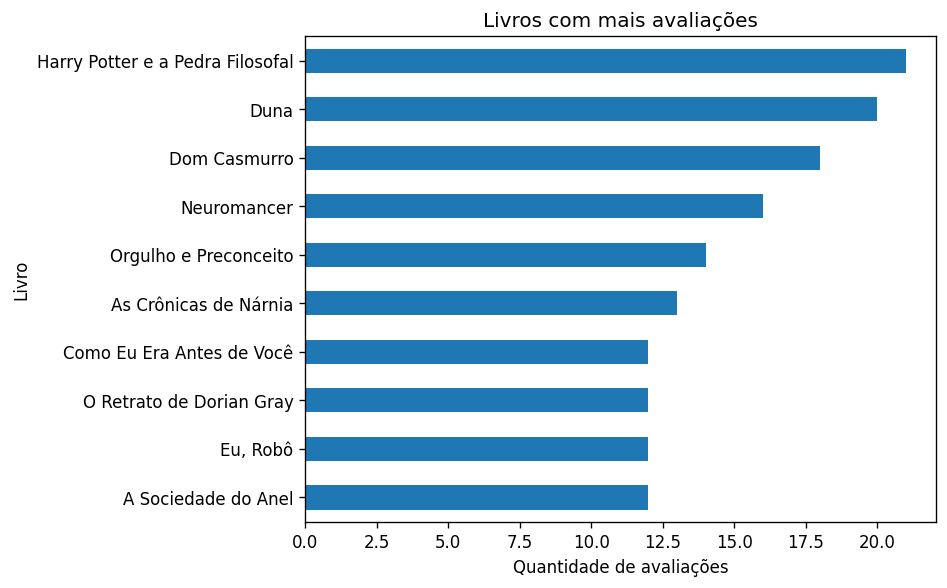

In [6]:
ratings_per_book = ratings.groupby("book_id").size().sort_values(ascending=False)
top_books = (
    ratings_per_book.head(10)
    .rename("avaliações")
    .to_frame()
    .join(books.set_index("book_id")[["title", "genres"]])
)
display(top_books[["title", "genres", "avaliações"]])

ax = top_books.set_index("title")["avaliações"].sort_values().plot(
    kind="barh", figsize=(8, 5), title="Livros com mais avaliações"
)
ax.set_xlabel("Quantidade de avaliações")
ax.set_ylabel("Livro")
plt.tight_layout()
plt.show()

## 7. Avaliações por gênero

,avaliações,nota_média
genres,,
Ficção Científica,78,3.53
Fantasia,71,3.80
Clássico,57,3.58
Romance,56,3.44
Distopia,44,3.75
Mistério,39,3.65


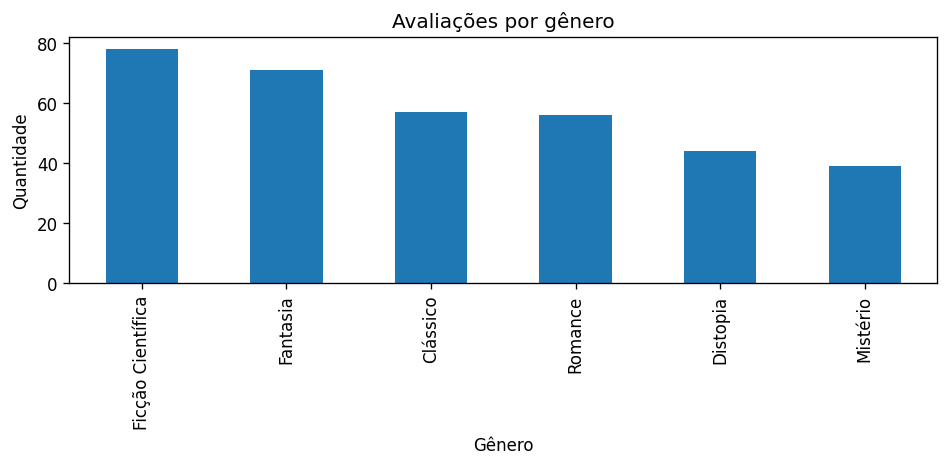

In [7]:
ratings_genre = ratings.merge(books[["book_id", "genres"]], on="book_id", how="left")
genre_summary = (
    ratings_genre.groupby("genres")
    .agg(avaliações=("rating", "size"), nota_média=("rating", "mean"))
    .sort_values("avaliações", ascending=False)
)
display(genre_summary.round(2))

ax = genre_summary["avaliações"].plot(kind="bar", figsize=(8, 4), title="Avaliações por gênero")
ax.set_xlabel("Gênero")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

## 8. Esparsidade

In [8]:
possible_pairs = n_users * rated_books
observed_pairs = len(ratings.drop_duplicates(["user_id", "book_id"]))
sparsity = 1 - observed_pairs / possible_pairs

print(f"Combinações possíveis: {possible_pairs}")
print(f"Combinações observadas: {observed_pairs}")
print(f"Esparsidade: {sparsity:.1%}")

Combinações possíveis: 1080
Combinações observadas: 345
Esparsidade: 68.1%


A esparsidade indica que a maior parte das combinações leitor–livro não possui avaliação. Isso reforça a necessidade de avaliar com cuidado a técnica de recomendação usada na N2.

## 9. Preparação dos dados

In [9]:
books_clean = (
    books.drop_duplicates()
    .sort_values("book_id")
    .reset_index(drop=True)
)

ratings_clean = (
    ratings.drop_duplicates()
    .sort_values(["user_id", "interaction_date", "book_id"])
    .reset_index(drop=True)
)

if not ratings_clean["rating"].between(1, 5).all():
    raise ValueError("Existem notas fora da escala de 1 a 5.")

if ratings_clean.duplicated(["user_id", "book_id"]).any():
    raise ValueError("Existem pares leitor-livro duplicados.")

if not set(ratings_clean["book_id"]).issubset(set(books_clean["book_id"])):
    raise ValueError("Existem avaliações de livros ausentes no catálogo.")

books_clean.to_csv(PROCESSED / "books_clean.csv", index=False)
ratings_clean.to_csv(
    PROCESSED / "ratings_clean.csv",
    index=False,
    date_format="%Y-%m-%d"
)

print("Arquivos tratados salvos em data/processed/.")

Arquivos tratados salvos em data/processed/.


## 10. Síntese da N1

O conjunto contém **30 leitores, 36 livros e 345 avaliações**. Não foram encontrados valores ausentes, duplicidades ou notas fora da escala definida. A nota média é aproximadamente **3,62**, com mediana **3,5**. A matriz leitor × livro apresenta **68,1% de esparsidade**.

Esses resultados sustentam o início da N2: existe histórico para testar uma estratégia personalizada, mas a base permanece esparsa, como ocorre em sistemas de recomendação. Na próxima etapa, um baseline não personalizado será comparado com uma abordagem adequada aos dados.